## **Training**

In [1]:
import os
import pandas as pd
from pathlib import Path
import sys
ROOT = next(
    path for path in [Path.cwd(), *Path.cwd().parents]
    if (path / 'kkthn').is_dir() and (path / 'notebooks').is_dir()
)
SRC = ROOT / 'kkthn' / 'src'
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from kkthn import KKTHardNet


In [2]:
# ----------------------------
# Config
# ----------------------------
DATA_PATH = "dataset/Pooling_dataset.csv"

PARAMETERS = ["x1", "x2", "x3", "x4"]
VARIABLES = ["y1", "y2", "y3", "y4", "y5"]

TRAIN = {
    "epochs": 1200,
    "batch_size": 40,
    "learning_rate": 1e-3,
    "train_frac": 0.8,   # 80/20 split handled internally
    "hidden_size": 64,
    "hidden_layers": 2,
    "seed": 42,
    "dtype": "float64",
    "print_every": 100,
    "newton_step_length": 0.5,
    "newton_tol": 1e-6,
    "newton_reg_factor": 1e-2,
    "max_newton_iter": 100,
    "max_backtrack_iter": 10,
    "eta": 75,
    "epoch_mlp": 100,
    "cons_alpha": 10
}


In [3]:
# ----------------------------
# Load and prepare dataset
# ----------------------------
df = pd.read_csv(DATA_PATH)

required_cols = PARAMETERS + VARIABLES
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing columns: {missing}")

# Select 2000 samples
df_2000 = (
    df[required_cols]
    .dropna()
    .sample(n=2000, random_state=TRAIN["seed"])
    .reset_index(drop=True)
)

# Save split files
os.makedirs("dataset", exist_ok=True)

param_path = "dataset/pooling_parameters_2000.csv"
var_path = "dataset/pooling_variables_2000.csv"

df_2000[PARAMETERS].to_csv(param_path, index=False)
df_2000[VARIABLES].to_csv(var_path, index=False)



In [4]:
# ----------------------------
# Build model
# ----------------------------
model = KKTHardNet(name="Pooling", train=TRAIN)

x = model.add_parameter(PARAMETERS)
y = model.add_variable(VARIABLES)

model.constraints.add(
    y.y2 + y.y3 - x.x1 - x.x2 == 0,
    x.x3 - y.y2 - y.y4 == 0,
    x.x4 - y.y3 - y.y5 == 0,
    y.y1 * y.y2 + y.y1 * y.y3 - 3 * x.x1 - x.x2 == 0,
    y.y1 * y.y2 + 2 * y.y4 - 2.5 * x.x3 <= 0,
    y.y1 * y.y3 + 2 * y.y5 - 1.5 * x.x4 <= 0,
)

model.dataset(
    parameters=param_path,
    variables=var_path,
)


In [5]:
# ----------------------------
# Train model
# ----------------------------
result = model.model()

Model training started! [2026-05-05 15:47:58]

KKT-HardNet
  dims: n_x=4 n_y=5 n_eq=4 n_ineq=2
  task: surrogate
  mode: forward
  samples: train=1600 val=400 batch_size=40
  network: [4, 64, 64, 5]
  eta: 75.0
  epoch_mlp: 100
  cons_alpha: 10.0
       Epoch |                Training                |               Validation              
------------------------------------------------------------------------------------------------------------------------
             |         Loss           Eq         Ineq |         Loss           Eq         Ineq
    001/1200 |   2.5223e+02   1.1231e+03   4.6302e+00 |   2.5869e+02   1.1328e+03   5.5092e+00
Switching to projection phase at epoch 8 (trigger: eta).
    100/1200 |   5.6315e+01   3.1462e-04   2.2935e-04 |   5.2246e+01   8.4641e-04   6.0840e-04
    200/1200 |   5.5841e+01   7.4533e-04   5.8384e-04 |   5.2545e+01   4.9526e-04   3.6482e-04
    300/1200 |   5.5843e+01   1.9172e-04   1.4207e-04 |   5.1992e+01   6.9588e-07   0.0000e+00
    4

In [6]:
model.summary()

📊 KKT-HardNet Summary
------------------------------------------------------------
Model Name                     : Pooling
No. of Parameters              : 4
No. of Variables               : 5
No. of Equalities              : 4
No. of Inequalities            : 2
No. of Train Samples           : 1600
No. of Validation Samples      : 400
Maximum Constraint Violation   : 0.0019
Training Time                  : 754.07 s
Est. JAX Single Inference Time : 0.19 ms
Est. JAX Batch Inference Time  : 2.66 ms
------------------------------------------------------------
Note: Inference time estimations are based on
microbenchmarking on the hardware used during
training and may vary across different hardware
and runtime conditions.


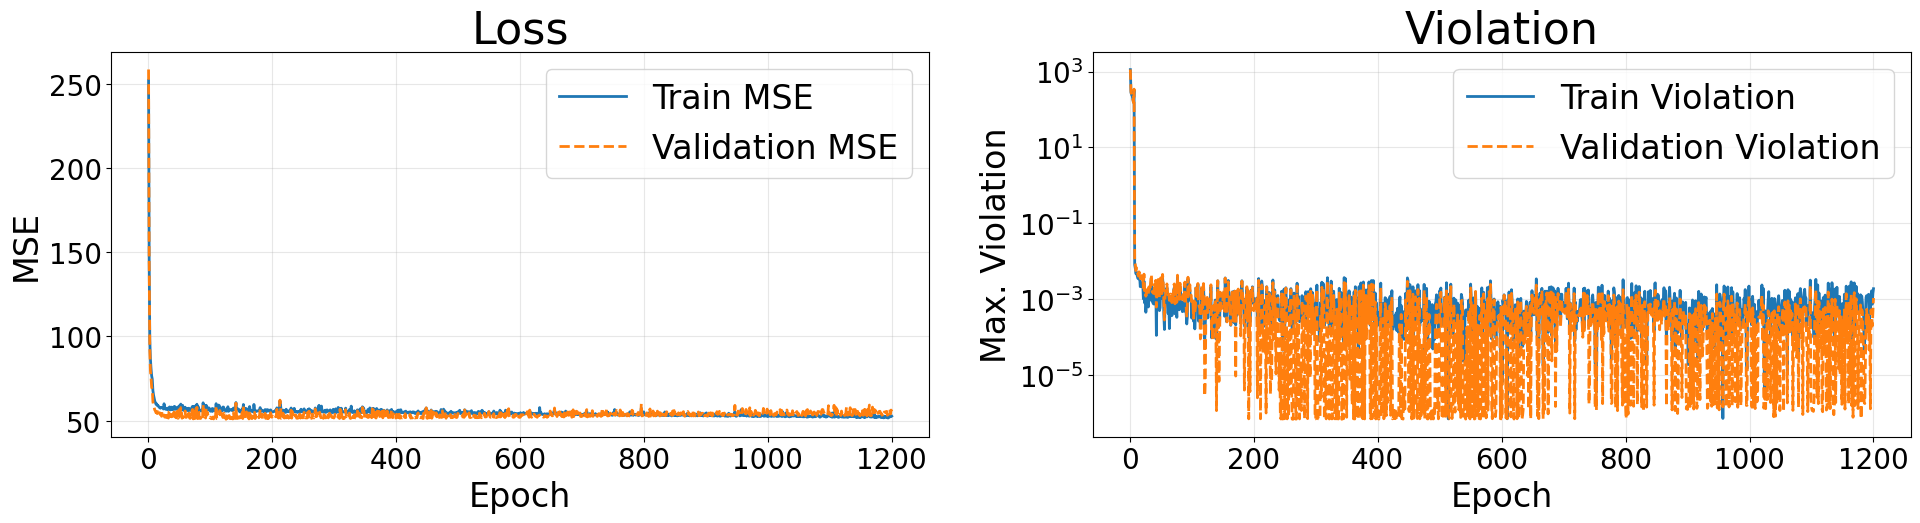

In [7]:
model.plot_history(bg="white")

## **Inference**

In [8]:
import os
import time
import pandas as pd
import numpy as np
from pathlib import Path
import sys
ROOT = next(
    path for path in [Path.cwd(), *Path.cwd().parents]
    if (path / 'kkthn').is_dir() and (path / 'notebooks').is_dir()
)
SRC = ROOT / 'kkthn' / 'src'
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from kkthn import KKTHardNet

In [10]:
# ----------------------------
# Get latest Pooling run
# ----------------------------
run_dirs = [
    d for d in os.listdir(".")
    if os.path.isdir(d) and d.startswith("Pooling")
]

latest_run_dir = max(run_dirs, key=os.path.getmtime)
metadata_path = os.path.join(latest_run_dir, "metadata.json")


In [11]:
# ----------------------------
# Load trained model
# ----------------------------
loaded_model = KKTHardNet()
loaded_model.load(metadata_path)



Model Loaded Successfully
------------------------------------------------------------------------------------------------------------------------
Model Name   : Pooling
Location     : /mnt/research/Hasan_Faruque/Shared/kkt-hardnet/notebooks/Pooling_20260505_154758
Time         : 2026-05-05 16:02:56



In [12]:

# ----------------------------
# Prepare inputs
# ----------------------------
PARAMETERS = ["x1", "x2", "x3", "x4"]
VARIABLES = ["y1", "y2", "y3", "y4", "y5"]

single_x = df_2000[PARAMETERS].iloc[0].tolist()
batch_x = df_2000[PARAMETERS].iloc[:50].values.tolist()


In [13]:
# ----------------------------
# Warm-up
# ----------------------------
loaded_model.predict(single_x, projection_backend="jax")
loaded_model.predict(batch_x, projection_backend="jax")

# ----------------------------
# Benchmark Single Instance
# ----------------------------
N_RUNS = 100

single_times = []
for _ in range(N_RUNS):
    start = time.perf_counter()
    loaded_model.predict(single_x, projection_backend="jax")
    single_times.append(time.perf_counter() - start)

single_times = np.array(single_times)
print(f"Single inference: {single_times.mean():.6e} ± {single_times.std():.6e} seconds")

Single inference: 1.810230e-04 ± 1.480710e-05 seconds


In [14]:
# ----------------------------
# Benchmark Single Instance
# ----------------------------
N_RUNS = 100

batch_times = []
for _ in range(N_RUNS):
    start = time.perf_counter()
    loaded_model.predict(batch_x, projection_backend="jax")
    batch_times.append(time.perf_counter() - start)

batch_times = np.array(batch_times)
print(f"Batch inference (50 samples): {batch_times.mean():.6e} ± {batch_times.std():.6e} seconds")

Batch inference (50 samples): 2.985465e-03 ± 2.419490e-04 seconds
